In [1]:
# this is to Import required libraries for start

import pandas as pd
import numpy as np


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define column names based on the UCI Heart Disease dataset documentation

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load the four processed UCI datasets

cleveland = pd.read_csv('processed.cleveland.data', names=columns, na_values='?')
hungarian = pd.read_csv('processed.hungarian.data', names=columns, na_values='?')
switzerland = pd.read_csv('processed.switzerland.data', names=columns, na_values='?')
va = pd.read_csv('processed.va.data', names=columns, na_values='?')

print("Datasets loaded successfully.")

print("Cleveland shape:", cleveland.shape)
print("Hungarian shape:", hungarian.shape)
print("Switzerland shape:", switzerland.shape)
print("VA Long Beach shape:", va.shape)

Datasets loaded successfully.
Cleveland shape: (303, 14)
Hungarian shape: (294, 14)
Switzerland shape: (123, 14)
VA Long Beach shape: (200, 14)


In [3]:
# Combine all datasets into one dataframe

heart_data = pd.concat(
    [cleveland, hungarian, switzerland, va],
    ignore_index=True
)

# Display shape of combined dataset

print("Combined dataset shape:", heart_data.shape)

# Preview first 5 rows

heart_data.head()

Combined dataset shape: (920, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# Basic information about the combined dataset

print("Dataset shape:", heart_data.shape)
print("\nColumn names:")
print(heart_data.columns.tolist())

print("\nDataset information:")
heart_data.info()

Dataset shape: (920, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 100.8 KB


In [5]:
# Statistical summary of numerical variables

heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [6]:
# Check missing values in each column

missing_values = heart_data.isnull().sum()

# Convert to dataframe for better readability

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values,
    'Percentage': (missing_values.values / len(heart_data)) * 100
})

# Sort by highest missing values

missing_df = missing_df.sort_values(by='Missing Values', ascending=False)

missing_df

,Column,Missing Values,Percentage
11,ca,611,66.413043
12,thal,486,52.826087
10,slope,309,33.586957
5,fbs,90,9.782609
9,oldpeak,62,6.739130
3,trestbps,59,6.413043
7,thalach,55,5.978261
8,exang,55,5.978261
4,chol,30,3.260870
6,restecg,2,0.217391


In [7]:
# Convert target variable into binary classification

heart_data['target'] = heart_data['target'].apply(lambda x: 0 if x == 0 else 1)

# Check class distribution

heart_data['target'].value_counts()

,count
target,
1,509
0,411


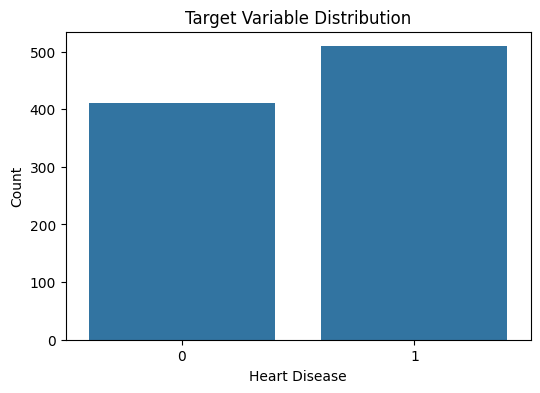

In [8]:
# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Create target distribution plot

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=heart_data)

plt.title('Target Variable Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')

plt.show()

In [9]:
# Check for duplicate rows

duplicates = heart_data.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 2


In [10]:
# Remove duplicate rows

heart_data = heart_data.drop_duplicates()

# Confirm duplicates removed

print("New dataset shape:", heart_data.shape)

print("Remaining duplicate rows:", heart_data.duplicated().sum())

New dataset shape: (918, 14)
Remaining duplicate rows: 0


In [11]:
# Impute continuous variables using median

heart_data['trestbps'].fillna(heart_data['trestbps'].median(), inplace=True)
heart_data['chol'].fillna(heart_data['chol'].median(), inplace=True)
heart_data['thalach'].fillna(heart_data['thalach'].median(), inplace=True)
heart_data['oldpeak'].fillna(heart_data['oldpeak'].median(), inplace=True)

# Impute categorical/discrete variables using mode

heart_data['fbs'].fillna(heart_data['fbs'].mode()[0], inplace=True)
heart_data['restecg'].fillna(heart_data['restecg'].mode()[0], inplace=True)
heart_data['exang'].fillna(heart_data['exang'].mode()[0], inplace=True)
heart_data['slope'].fillna(heart_data['slope'].mode()[0], inplace=True)
heart_data['ca'].fillna(heart_data['ca'].mode()[0], inplace=True)
heart_data['thal'].fillna(heart_data['thal'].mode()[0], inplace=True)

# Check remaining missing values

heart_data.isnull().sum()

/tmp/ipykernel_2430/4015267610.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_data['trestbps'].fillna(heart_data['trestbps'].median(), inplace=True)
/tmp/ipykernel_2430/4015267610.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


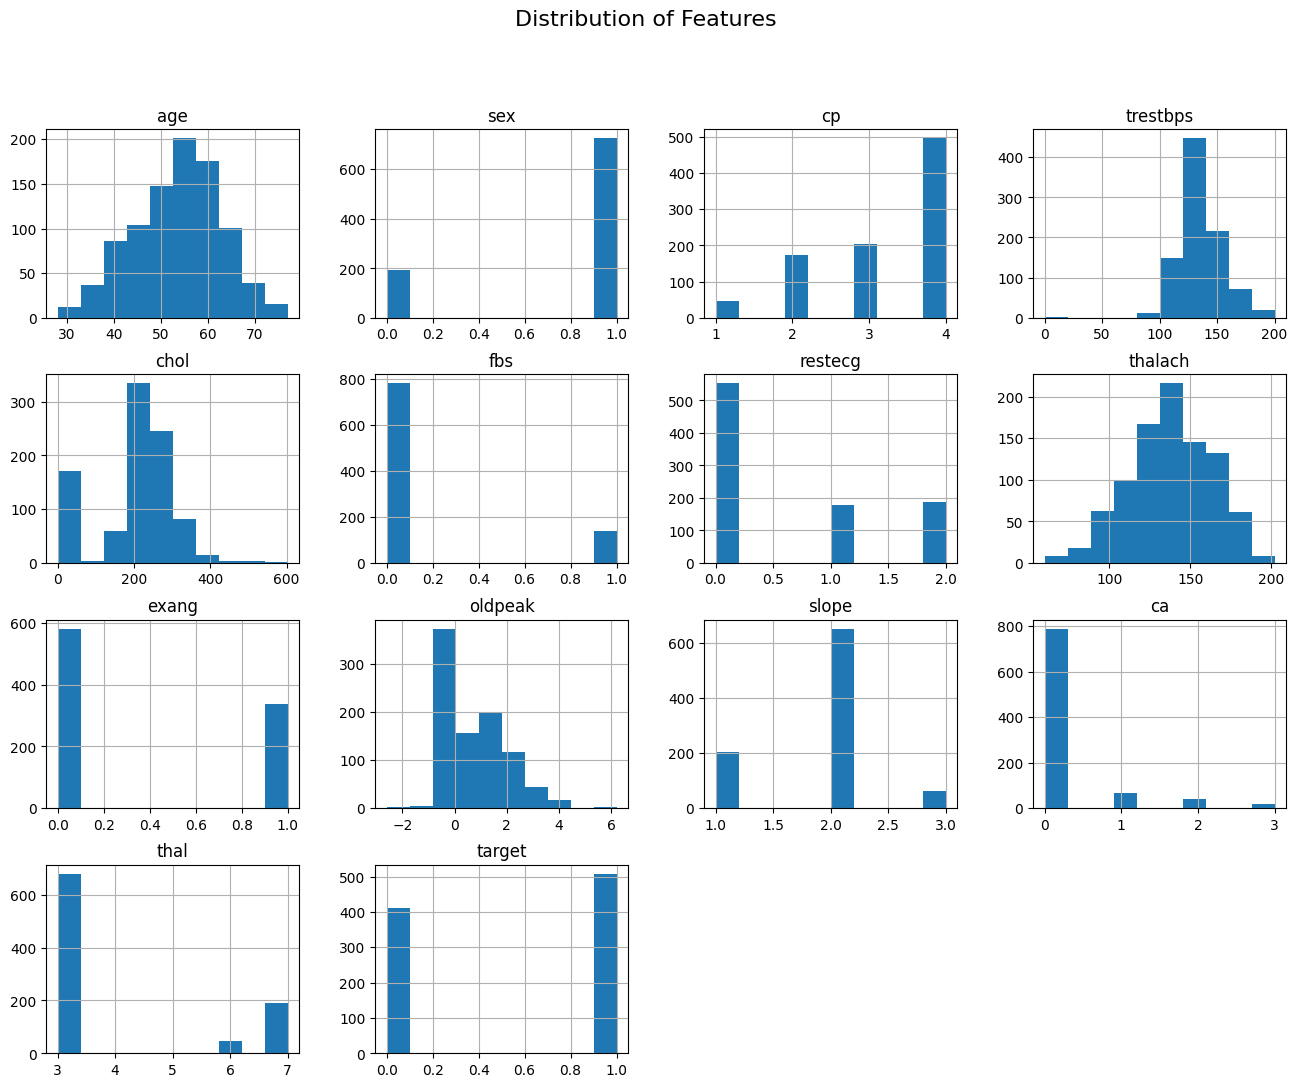

In [12]:
# Plot histograms for numerical variables

heart_data.hist(figsize=(16,12))

plt.suptitle('Distribution of Features', fontsize=16)

plt.show()

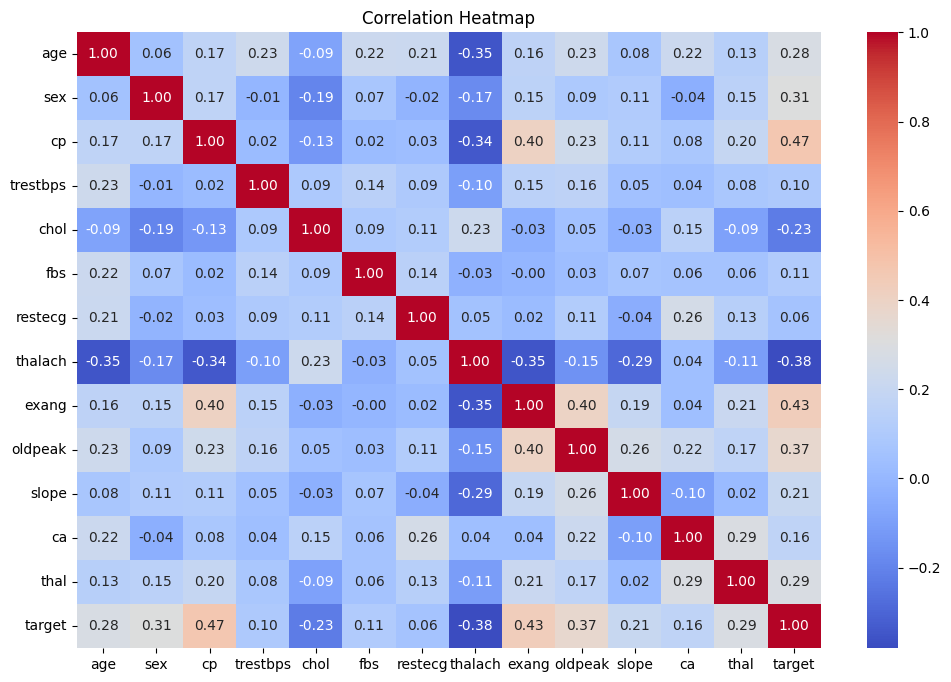

In [13]:
# Create correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    heart_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [14]:
# Separate features and target variable

X = heart_data.drop('target', axis=1)

y = heart_data['target']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (918, 13)
Target vector shape: (918,)


In [15]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

# Initialize scaler

scaler = StandardScaler()

# Scale the feature matrix

X_scaled = scaler.fit_transform(X)

# Convert scaled data back to dataframe

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Preview scaled data

X_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,1.006537,0.515952,-2.419749,0.705085,0.303747,2.377430,1.733661,0.489681,-0.759815,1.365834,2.232505,-0.361845,1.198054
1,1.430829,0.515952,0.804242,1.518645,0.789562,-0.420622,1.733661,-1.180980,1.316109,0.609600,0.295417,4.406195,-0.587357
2,1.430829,0.515952,0.804242,-0.650848,0.267081,-0.420622,1.733661,-0.345649,1.316109,1.649422,0.295417,2.816848,1.793191
3,-1.751359,0.515952,-0.270422,-0.108475,0.459574,-0.420622,-0.749180,1.961454,-0.759815,2.500185,2.232505,-0.361845,-0.587357
4,-1.327067,-1.938163,-1.345086,-0.108475,0.037923,-0.420622,1.733661,1.364789,-0.759815,0.515071,-1.641672,-0.361845,-0.587357


In [16]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (734, 13)
X_test shape: (184, 13)
y_train shape: (734,)
y_test shape: (184,)


In [17]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model

rf_model.fit(X_train, y_train)

# Make predictions

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [18]:
# Import evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Evaluate Random Forest model

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print("Random Forest Performance")
print("--------------------------")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)
print("ROC-AUC:", rf_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Performance
--------------------------
Accuracy: 0.8315217391304348
Precision: 0.8446601941747572
Recall: 0.8529411764705882
F1-score: 0.848780487804878
ROC-AUC: 0.9117049258727882

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        82
           1       0.84      0.85      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184


Confusion Matrix:
[[66 16]
 [15 87]]


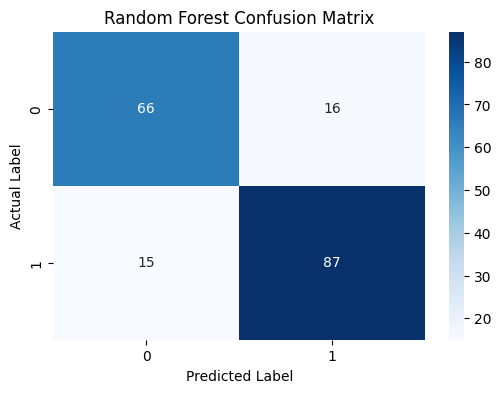

In [19]:
# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [20]:
!pip install xgboost

In [21]:
# Import XGBoost

from xgboost import XGBClassifier

# Create XGBoost model

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

# Train the model

xgb_model.fit(X_train, y_train)

# Make predictions

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [22]:
# Evaluate XGBoost model

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print("XGBoost Performance")
print("---------------------")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1-score:", xgb_f1)
print("ROC-AUC:", xgb_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Performance
---------------------
Accuracy: 0.842391304347826
Precision: 0.8411214953271028
Recall: 0.8823529411764706
F1-score: 0.861244019138756
ROC-AUC: 0.9146341463414633

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:
[[65 17]
 [12 90]]


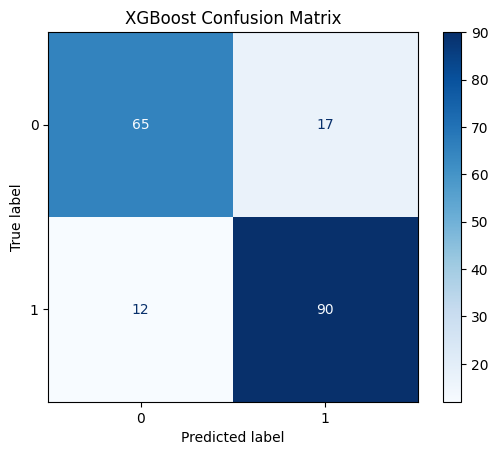

In [23]:
# XGBoost Confusion Matrix Visualization

from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title('XGBoost Confusion Matrix')

plt.show()

Hyperparameter Tuning using GridSearchCV

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
# Random Forest Hyperparameter Tuning using GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Random Forest GridSearchCV completed successfully.")
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)
print("Best Cross-Validation Accuracy:")
print(rf_grid.best_score_)

Random Forest GridSearchCV completed successfully.
Best Random Forest Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy:
0.8201845121610287


In [26]:
# Evaluate Tuned Random Forest Model

best_rf_model = rf_grid.best_estimator_

rf_tuned_pred = best_rf_model.predict(X_test)
rf_tuned_prob = best_rf_model.predict_proba(X_test)[:, 1]

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(y_test, rf_tuned_pred)
rf_tuned_recall = recall_score(y_test, rf_tuned_pred)
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred)
rf_tuned_auc = roc_auc_score(y_test, rf_tuned_prob)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("Accuracy:", rf_tuned_accuracy)
print("Precision:", rf_tuned_precision)
print("Recall:", rf_tuned_recall)
print("F1-score:", rf_tuned_f1)
print("ROC-AUC:", rf_tuned_auc)

print("\nClassification Report:")
print(classification_report(y_test, rf_tuned_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_tuned_pred))

Tuned Random Forest Performance
--------------------------------
Accuracy: 0.8260869565217391
Precision: 0.8181818181818182
Recall: 0.8823529411764706
F1-score: 0.8490566037735849
ROC-AUC: 0.9155906264945003

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.79        82
           1       0.82      0.88      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.82       184


Confusion Matrix:
[[62 20]
 [12 90]]


In [27]:
# XGBoost Hyperparameter Tuning using GridSearchCV

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("XGBoost GridSearchCV completed successfully.")
print("Best Parameters:")
print(xgb_grid.best_params_)
print("Best Cross-Validation Accuracy:")
print(xgb_grid.best_score_)

XGBoost GridSearchCV completed successfully.
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validation Accuracy:
0.8092535644394745


In [28]:
# Evaluate Tuned XGBoost Model

best_xgb_model = xgb_grid.best_estimator_

xgb_tuned_pred = best_xgb_model.predict(X_test)
xgb_tuned_prob = best_xgb_model.predict_proba(X_test)[:, 1]

xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_pred)
xgb_tuned_precision = precision_score(y_test, xgb_tuned_pred)
xgb_tuned_recall = recall_score(y_test, xgb_tuned_pred)
xgb_tuned_f1 = f1_score(y_test, xgb_tuned_pred)
xgb_tuned_auc = roc_auc_score(y_test, xgb_tuned_prob)

print("Tuned XGBoost Performance")
print("-------------------------")
print("Accuracy:", xgb_tuned_accuracy)
print("Precision:", xgb_tuned_precision)
print("Recall:", xgb_tuned_recall)
print("F1-score:", xgb_tuned_f1)
print("ROC-AUC:", xgb_tuned_auc)

print("\nClassification Report:")
print(classification_report(y_test, xgb_tuned_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_tuned_pred))

Tuned XGBoost Performance
-------------------------
Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154
ROC-AUC: 0.9232424677187948

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184


Confusion Matrix:
[[66 16]
 [12 90]]


In [29]:
comparison_tuned = pd.DataFrame({
    'Model': ['Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'Accuracy': [rf_tuned_accuracy, xgb_tuned_accuracy],
    'Precision': [rf_tuned_precision, xgb_tuned_precision],
    'Recall': [rf_tuned_recall, xgb_tuned_recall],
    'F1-Score': [rf_tuned_f1, xgb_tuned_f1],
    'ROC-AUC': [rf_tuned_auc, xgb_tuned_auc]
})

comparison_tuned

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest (Tuned),0.826087,0.818182,0.882353,0.849057,0.915591
1,XGBoost (Tuned),0.847826,0.849057,0.882353,0.865385,0.923242


DEEP LEARNING IMPLEMENTATION

In [30]:
# Import TensorFlow and Keras

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow imported successfully.")

TensorFlow imported successfully.


In [31]:
# Build Artificial Neural Network model

ann_model = Sequential()

# Input layer and first hidden layer
ann_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
ann_model.add(Dense(32, activation='relu'))

# Output layer for binary classification
ann_model.add(Dense(1, activation='sigmoid'))

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Train the ANN model

history = ann_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6951 - loss: 0.6124 - val_accuracy: 0.8095 - val_loss: 0.5157
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7905 - loss: 0.5011 - val_accuracy: 0.8231 - val_loss: 0.4570
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7990 - loss: 0.4484 - val_accuracy: 0.8231 - val_loss: 0.4344
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8126 - loss: 0.4237 - val_accuracy: 0.8231 - val_loss: 0.4271
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8211 - loss: 0.4113 - val_accuracy: 0.8163 - val_loss: 0.4261
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8279 - loss: 0.4023 - val_accuracy: 0.8163 - val_loss: 0.4244
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8330 - loss: 0.3944 - val_accuracy: 0.8231 - val_loss: 0.4267
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8330 - loss: 0.3876 - val_accuracy: 0.8163 - v

In [33]:
# Generate ANN predictions

y_pred_ann = ann_model.predict(X_test)

# Convert probabilities to binary predictions

y_pred_ann = (y_pred_ann > 0.5).astype(int)

# Flatten predictions

y_pred_ann = y_pred_ann.flatten()

# Evaluate ANN model

ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)
ann_auc = roc_auc_score(y_test, y_pred_ann)

print("ANN Performance")
print("----------------")
print("Accuracy:", ann_accuracy)
print("Precision:", ann_precision)
print("Recall:", ann_recall)
print("F1-score:", ann_f1)
print("ROC-AUC:", ann_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
ANN Performance
----------------
Accuracy: 0.8206521739130435
Precision: 0.8415841584158416
Recall: 0.8333333333333334
F1-score: 0.8374384236453202
ROC-AUC: 0.8191056910569107

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        82
           1       0.84      0.83      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184


Confusion Matrix:
[[66 16]
 [17 85]]


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


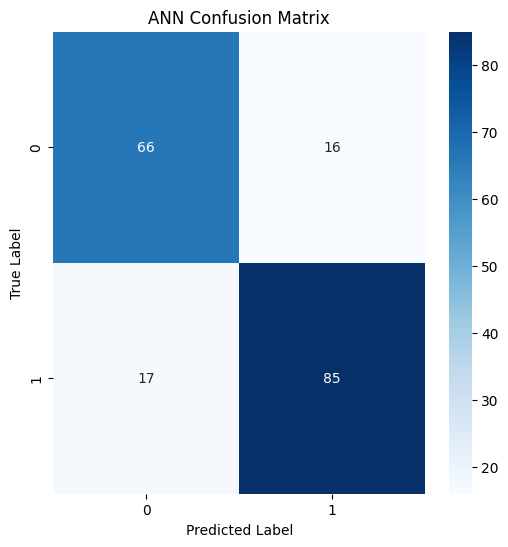

In [34]:
# Generate ANN predictions

ann_pred_prob = ann_model.predict(X_test)

ann_pred = (ann_pred_prob > 0.5).astype(int)

# ANN Confusion Matrix Visualization

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix

ann_cm = confusion_matrix(y_test, ann_pred)

# Plot confusion matrix

plt.figure(figsize=(6,6))

sns.heatmap(
    ann_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [35]:
# Reshape data for LSTM

X_train_lstm = np.reshape(
    X_train.values,
    (X_train.shape[0], X_train.shape[1], 1)
)

X_test_lstm = np.reshape(
    X_test.values,
    (X_test.shape[0], X_test.shape[1], 1)
)

print("LSTM training shape:", X_train_lstm.shape)
print("LSTM testing shape:", X_test_lstm.shape)

LSTM training shape: (734, 13, 1)
LSTM testing shape: (184, 13, 1)


In [36]:
# Import LSTM layer

from tensorflow.keras.layers import LSTM, Dropout

# Build LSTM model

lstm_model = Sequential()

lstm_model.add(LSTM(
    units=64,
    activation='tanh',
    input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
))

lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(32, activation='relu'))

lstm_model.add(Dense(1, activation='sigmoid'))

# Compile LSTM model

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train LSTM model

lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6729 - loss: 0.6690 - val_accuracy: 0.7279 - val_loss: 0.6228
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7104 - loss: 0.6004 - val_accuracy: 0.7075 - val_loss: 0.5720
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7019 - loss: 0.5744 - val_accuracy: 0.7075 - val_loss: 0.5487
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7189 - loss: 0.5633 - val_accuracy: 0.7007 - val_loss: 0.5480
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7291 - loss: 0.5609 - val_accuracy: 0.7075 - val_loss: 0.5436
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7223 - loss: 0.5538 - val_accuracy: 0.7279 - val_loss: 0.5428
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7308 - loss: 0.5434 - val_accuracy: 0.7551 - val_loss: 0.5328
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7411 - loss: 0.5405 - val_accuracy: 0.7619 - v

In [38]:
# Generate LSTM predictions

y_pred_lstm = lstm_model.predict(X_test_lstm)

# Convert probabilities to binary predictions

y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

# Flatten predictions

y_pred_lstm = y_pred_lstm.flatten()

# Evaluate LSTM model

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
lstm_precision = precision_score(y_test, y_pred_lstm)
lstm_recall = recall_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)
lstm_auc = roc_auc_score(y_test, y_pred_lstm)

print("LSTM Performance")
print("-----------------")
print("Accuracy:", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall:", lstm_recall)
print("F1-score:", lstm_f1)
print("ROC-AUC:", lstm_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lstm))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
LSTM Performance
-----------------
Accuracy: 0.8097826086956522
Precision: 0.819047619047619
Recall: 0.8431372549019608
F1-score: 0.8309178743961353
ROC-AUC: 0.8057149689143951

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        82
           1       0.82      0.84      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184


Confusion Matrix:
[[63 19]
 [16 86]]


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


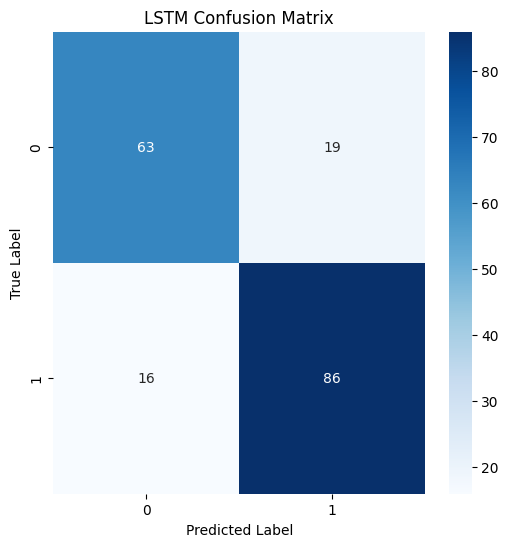

In [39]:

# Generate LSTM predictions

lstm_pred_prob = lstm_model.predict(X_test_lstm)

lstm_pred = (lstm_pred_prob > 0.5).astype(int)
# LSTM Confusion Matrix Visualization

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix

lstm_cm = confusion_matrix(y_test, lstm_pred)

# Plot confusion matrix

plt.figure(figsize=(6,6))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [40]:
# Create model comparison table

model_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'ANN', 'LSTM'],
    'Accuracy': [rf_accuracy, xgb_accuracy, ann_accuracy, lstm_accuracy],
    'Precision': [rf_precision, xgb_precision, ann_precision, lstm_precision],
    'Recall': [rf_recall, xgb_recall, ann_recall, lstm_recall],
    'F1-Score': [rf_f1, xgb_f1, ann_f1, lstm_f1],
    'ROC-AUC': [rf_auc, xgb_auc, ann_auc, lstm_auc]
})

# Round values to 4 decimal places

model_results = model_results.round(4)

# Display table

model_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8315,0.8447,0.8529,0.8488,0.9117
1,XGBoost,0.8424,0.8411,0.8824,0.8612,0.9146
2,ANN,0.8207,0.8416,0.8333,0.8374,0.8191
3,LSTM,0.8098,0.8190,0.8431,0.8309,0.8057


In [41]:
# Create professional percentage-based results table

results_table = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'ANN', 'LSTM'],

    'Accuracy': [
        f"{rf_accuracy*100:.2f}%",
        f"{xgb_accuracy*100:.2f}%",
        f"{ann_accuracy*100:.2f}%",
        f"{lstm_accuracy*100:.2f}%"
    ],

    'Recall': [
        f"{rf_recall*100:.2f}%",
        f"{xgb_recall*100:.2f}%",
        f"{ann_recall*100:.2f}%",
        f"{lstm_recall*100:.2f}%"
    ],

    'F1': [
        f"{rf_f1*100:.2f}%",
        f"{xgb_f1*100:.2f}%",
        f"{ann_f1*100:.2f}%",
        f"{lstm_f1*100:.2f}%"
    ],

    'ROC-AUC': [
        f"{rf_auc*100:.2f}%",
        f"{xgb_auc*100:.2f}%",
        f"{ann_auc*100:.2f}%",
        f"{lstm_auc*100:.2f}%"
    ]
})

# Display final table

results_table

,Model,Accuracy,Recall,F1,ROC-AUC
0,Random Forest,83.15%,85.29%,84.88%,91.17%
1,XGBoost,84.24%,88.24%,86.12%,91.46%
2,ANN,82.07%,83.33%,83.74%,81.91%
3,LSTM,80.98%,84.31%,83.09%,80.57%


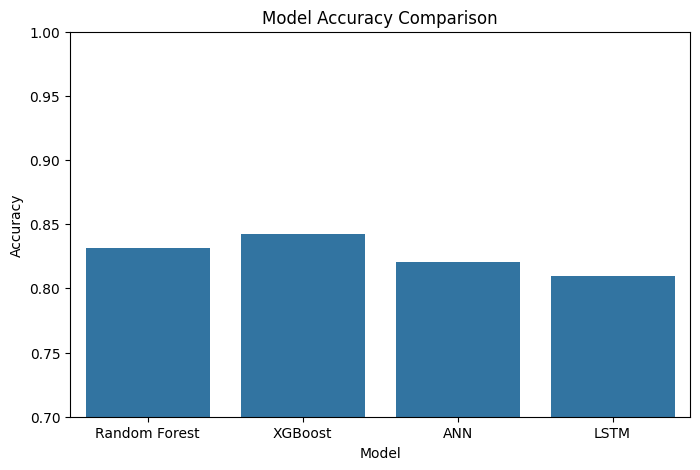

In [42]:
# Plot model accuracy comparison

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.ylim(0.7, 1.0)

plt.show()

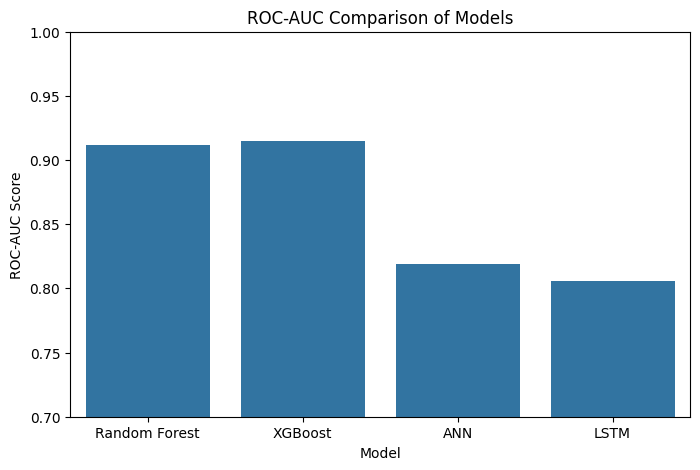

In [43]:
# Plot ROC-AUC comparison chart

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=model_results
)

plt.title('ROC-AUC Comparison of Models')
plt.ylabel('ROC-AUC Score')

plt.ylim(0.7, 1.0)

plt.show()

In [44]:
# Extract feature importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance table

feature_importance

,Feature,Importance
2,cp,0.151656
7,thalach,0.137709
4,chol,0.136569
0,age,0.126043
9,oldpeak,0.106154
8,exang,0.082890
3,trestbps,0.082841
12,thal,0.039220
1,sex,0.035441
6,restecg,0.033551


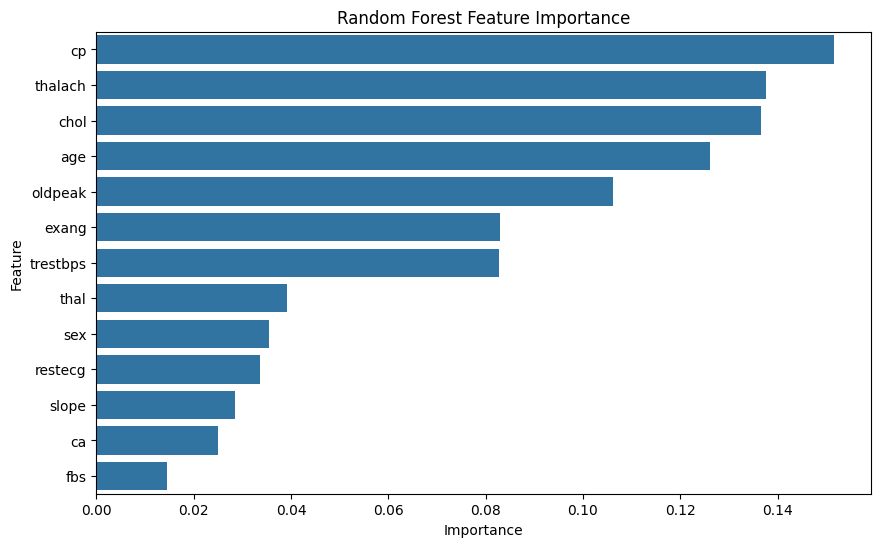

In [45]:
# Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Random Forest Feature Importance')

plt.show()